# Fake News Classifier

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline
import joblib


pd.set_option('display.max_colwidth', 100)

In [2]:
fake = pd.read_csv('Data/Fake.csv')
real = pd.read_csv('Data/True.csv')

fake['label'] = 0  
real['label'] = 1  

print(fake.shape, real.shape)
print(fake.columns.tolist())
fake.head(3)

(23481, 5) (21417, 5)
['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he...",News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under th...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered ...",News,"December 30, 2017",0


In [3]:
df = pd.concat([fake, real], axis=0, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  

print(df.shape)
print(df['label'].value_counts())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df['subject'].value_counts())

(44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64
title      0
text       0
subject    0
date       0
label      0
dtype: int64
209
subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


In [4]:
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)

df['content'] = df['title'] + " " + df['text']
df = df[['content', 'label']]

df['text_length'] = df['content'].str.len()
df.groupby('label')['text_length'].describe()

(44689, 5)


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,23478.0,2642.749936,2533.838628,31.0,1530.25,2259.0,3126.0,51893.0
1,21211.0,2443.700627,1684.042483,32.0,971.50,2282.0,3291.5,29849.0


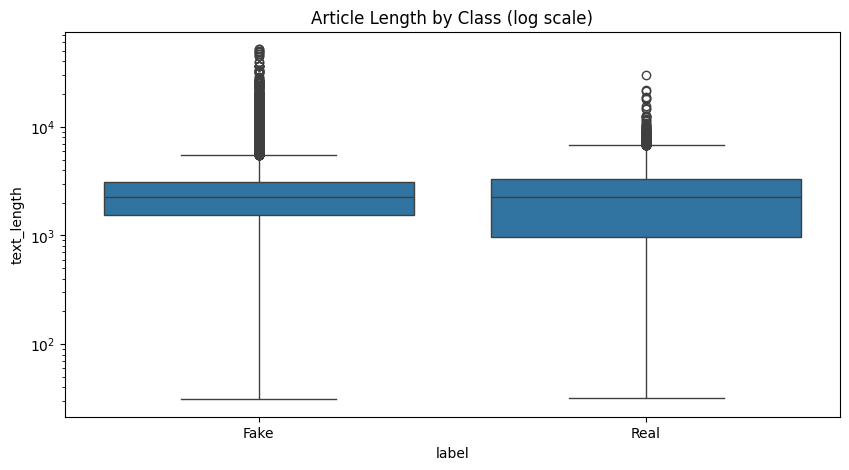

In [5]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='label', y='text_length')
plt.yscale('log')
plt.xticks([0,1], ['Fake', 'Real'])
plt.title('Article Length by Class (log scale)')
plt.show()

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\(reuters\)', '', text)           
    text = re.sub(r'reuters', '', text)               
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_content'] = df['content'].apply(clean_text)
df[['content', 'clean_content']].head(3)

,content,clean_content
0,Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st C...,ben stein calls out th circuit court committed a coup dtat against the constitution st century w...
1,Trump drops Steve Bannon from National Security Council WASHINGTON (Reuters) - U.S. President Do...,trump drops steve bannon from national security council washington us president donald trump rem...
2,Puerto Rico expects U.S. to lift Jones Act shipping restrictions (Reuters) - Puerto Rico Governo...,puerto rico expects us to lift jones act shipping restrictions puerto rico governor ricardo ross...


In [8]:
X = df['clean_content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(35751, 5000) (8938, 5000)


In [10]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred = lr_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4696
        Real       0.98      0.99      0.98      4242

    accuracy                           0.98      8938
   macro avg       0.98      0.98      0.98      8938
weighted avg       0.98      0.98      0.98      8938

[[4604   92]
 [  45 4197]]


In [13]:
pipeline = make_pipeline(tfidf, lr_model)

explainer = LimeTextExplainer(class_names=['Fake', 'Real'])

idx = 5
text_sample = X_test.iloc[idx]
true_label = y_test.iloc[idx]

exp = explainer.explain_instance(text_sample, pipeline.predict_proba, num_features=10)
print(f"True label: {'Real' if true_label == 1 else 'Fake'}")
for word, weight in exp.as_list():
    print(f"{word}: {weight:.4f}")

True label: Fake
old: -0.1149
just: -0.0723
woman: -0.0554
yearold: 0.0499
year: 0.0431
said: 0.0397
flag: -0.0378
court: 0.0252
sentenced: 0.0233
wednesday: 0.0169


In [14]:
pred_proba = pipeline.predict_proba([text_sample])[0]
print(f"P(Fake)={pred_proba[0]:.4f}, P(Real)={pred_proba[1]:.4f}")
print(f"Predicted: {'Real' if pred_proba[1] > 0.5 else 'Fake'}, True: {'Real' if true_label == 1 else 'Fake'}")

P(Fake)=0.8327, P(Real)=0.1673
Predicted: Fake, True: Fake


In [17]:
y_pred_array = np.array(y_pred)
y_test_array = y_test.values

misclassified_idx = np.where(y_pred_array != y_test_array)[0]
print(f"Number of misclassified: {len(misclassified_idx)}")

idx2 = misclassified_idx[0]
text_sample2 = X_test.iloc[idx2]
true_label2 = y_test.iloc[idx2]

exp2 = explainer.explain_instance(text_sample2, pipeline.predict_proba, num_features=10)
print(f"True label: {'Real' if true_label2 == 1 else 'Fake'}")
for word, weight in exp2.as_list():
    print(f"{word}: {weight:.4f}")

Number of misclassified: 137
True label: Real
said: 0.3080
mayor: -0.1890
county: -0.0844
thursday: 0.0690
prosecutors: 0.0647
criminal: -0.0482
strip: -0.0452
court: 0.0401
republican: 0.0202
statement: 0.0156


In [18]:
pred_proba2 = pipeline.predict_proba([text_sample2])[0]
print(f"P(Fake)={pred_proba2[0]:.4f}, P(Real)={pred_proba2[1]:.4f}")

P(Fake)=0.5003, P(Real)=0.4997


In [21]:
joblib.dump(lr_model, 'Models/fakenews_model.pkl')
joblib.dump(tfidf, 'Models/fakenews_vectorizer.pkl')

print("saved")

saved
